In [1]:
{
 "nbformat": 4,
 "nbformat_minor": 5,
 "metadata": {
  "kernelspec": {
   "display_name": "Python 3",
   "language": "python",
   "name": "python3"
  }
 },
 "cells": [
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "# 🍼 Reproducible Demonstration Notebook\n",
    "## Polluted CutMix + Uncertainty-Aware Consistency Learning (Toy Example)\n",
    "\n",
    "This notebook provides a *reproducible demonstration* of the key components in our training pipeline, including:\n",
    "- Data loading structure\n",
    "- Polluted CutMix augmentation\n",
    "- Uncertainty estimation (toy MC-dropout example)\n",
    "- Semi-supervised consistency regularization\n",
    "- EMA teacher update mechanism\n",
    "\n",
    "**Note:** For privacy and computational constraints, this notebook uses *toy data* and *simplified modules* rather than the full clinical dataset and complete PyTorch training framework. The goal is to illustrate the pipeline logic clearly while enabling reproducibility."
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 1,
   "metadata": {},
   "outputs": [],
   "source": [
    "%matplotlib inline\n",
    "import numpy as np\n",
    "import matplotlib.pyplot as plt\n",
    "import torch\n",
    "import torch.nn.functional as F\n",
    "from torch import nn\n",
    "print(\"✅ Environment setup completed!\")"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 2,
   "metadata": {},
   "outputs": [],
   "source": [
    "def load_dummy_image(size=256):\n",
    "    \"\"\"Simulate a 256×256 neonatal chest image.\"\"\"\n",
    "    return np.random.rand(size, size)\n",
    "\n",
    "img1 = load_dummy_image()\n",
    "img2 = load_dummy_image()\n",
    "\n",
    "print(f\"Generated sample images with shape: {img1.shape}\")\n",
    "plt.figure(figsize=(6, 6))\n",
    "plt.imshow(img1, cmap='gray')\n",
    "plt.title('Dummy Sample Image')\n",
    "plt.axis('off')\n",
    "plt.show()"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 3,
   "metadata": {},
   "outputs": [],
   "source": [
    "def toy_cutmix(x1, x2, lam=0.5):\n",
    "    return lam * x1 + (1 - lam) * x2\n",
    "\n",
    "mixed = toy_cutmix(img1, img2, lam=0.6)\n",
    "\n",
    "print(\"Applying Polluted CutMix...\")\n",
    "plt.figure(figsize=(6, 6))\n",
    "plt.imshow(mixed, cmap='gray')\n",
    "plt.title('Polluted CutMix Result (Toy Example)')\n",
    "plt.axis('off')\n",
    "plt.show()"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 4,
   "metadata": {},
   "outputs": [],
   "source": [
    "class DummyModel(nn.Module):\n",
    "    def __init__(self):\n",
    "        super().__init__()\n",
    "        self.fc = nn.Linear(256*256, 2)\n",
    "\n",
    "    def forward(self, x):\n",
    "        x = x.reshape(1, -1)\n",
    "        return self.fc(x)\n",
    "\n",
    "model = DummyModel()\n",
    "dummy_input = torch.tensor(img1, dtype=torch.float32)\n",
    "output = model(dummy_input)\n",
    "print(f\"Model output shape: {output.shape}\")\n",
    "print(f\"Model output values: {output.detach().numpy()}\")"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 5,
   "metadata": {},
   "outputs": [],
   "source": [
    "def update_ema(student, teacher, alpha=0.99):\n",
    "    for t_param, s_param in zip(teacher.parameters(), student.parameters()):\n",
    "        t_param.data = alpha * t_param.data + (1 - alpha) * s_param.data\n",
    "\n",
    "teacher = DummyModel()\n",
    "update_ema(model, teacher)\n",
    "print('EMA update applied.')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 6,
   "metadata": {},
   "outputs": [],
   "source": [
    "def mc_dropout_uncertainty(x, T=8):\n",
    "    preds = []\n",
    "    for _ in range(T):\n",
    "        noise = np.random.normal(0, 0.1, x.shape)\n",
    "        preds.append(x + noise)\n",
    "    preds = np.stack(preds)\n",
    "    return np.var(preds)\n",
    "\n",
    "uncert = mc_dropout_uncertainty(img1)\n",
    "print(f\"Uncertainty estimate: {uncert:.6f}\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## Pseudo-code: Full Training Pipeline\n",
    "\n",
    "```python\n",
    "for epoch in range(max_epochs):\n",
    "    for labeled_batch, unlabeled_batch in loader:\n",
    "\n",
    "        # ----- 1. Supervised Loss (CutMix) -----\n",
    "        mixed_x, y_a, y_b, lam = cutmix(labeled_batch)\n",
    "        loss_ce = lam * CE(model(mixed_x), y_a) + (1-lam) * CE(model(mixed_x), y_b)\n",
    "\n",
    "        # ----- 2. Unlabeled Consistency Loss -----\n",
    "        stu_pred = softmax(model(unlabeled_batch))\n",
    "        tea_pred = softmax(ema_model(unlabeled_batch))\n",
    "        consistency_loss = MSE(stu_pred, tea_pred)\n",
    "\n",
    "        # ----- 3. Uncertainty Mask -----\n",
    "        uncertainty = entropy(tea_pred)\n",
    "        mask = (uncertainty < threshold).float()\n",
    "        consistency_loss = (mask * consistency_loss).mean()\n",
    "\n",
    "        # ----- 4. Total Loss -----\n",
    "        loss = loss_ce + w * consistency_loss\n",
    "        loss.backward()\n",
    "        optimizer.step()\n",
    "\n",
    "        # ----- 5. EMA Update -----\n",
    "        update_ema(model, ema_model)\n",
    "```"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 7,
   "metadata": {},
   "outputs": [],
   "source": [
    "def dummy_inference(x):\n",
    "    return {\n",
    "        \"Accuracy\": 0.80,\n",
    "        \"Sensitivity\": 0.78,\n",
    "        \"Precision\": 0.82\n",
    "    }\n",
    "\n",
    "results = dummy_inference(img1)\n",
    "print(\"Simulated inference results:\")\n",
    "for key, value in results.items():\n",
    "    print(f\"  {key}: {value}\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## How to Run the Full Training Pipeline\n",
    "\n",
    "To reproduce the complete experiments in the paper, run the following command:\n",
    "\n",
    "```bash\n",
    "python train_Xi_Ru.py \\\n",
    "    --model DenseNet_2_class \\\n",
    "    --exp AS \\\n",
    "    --labeled_num 136 \\\n",
    "    --root_path /path/to/dataset\n",
    "```\n",
    "\n",
    "This will:\n",
    "1. Load the Xi-Ru neonatal dataset\n",
    "2. Apply Polluted CutMix augmentation\n",
    "3. Apply uncertainty-aware consistency regularization\n",
    "4. Train student + EMA teacher networks\n",
    "5. Evaluate on validation & test sets\n",
    "6. Automatically save best-performing models and logs\n",
    "\n",
    "The purpose of this notebook is to provide a **transparent, runnable, and reproducible demonstration** of the main algorithmic components without relying on protected clinical data."
   ]
  }
 ]
}

{'nbformat': 4,
 'nbformat_minor': 5,
 'metadata': {'kernelspec': {'display_name': 'Python 3',
   'language': 'python',
   'name': 'python3'}},
 'cells': [{'cell_type': 'markdown',
   'metadata': {},
   'source': ['# 🍼 Reproducible Demonstration Notebook\n',
    '## Polluted CutMix + Uncertainty-Aware Consistency Learning (Toy Example)\n',
    '\n',
    'This notebook provides a *reproducible demonstration* of the key components in our training pipeline, including:\n',
    '- Data loading structure\n',
    '- Polluted CutMix augmentation\n',
    '- Uncertainty estimation (toy MC-dropout example)\n',
    '- Semi-supervised consistency regularization\n',
    '- EMA teacher update mechanism\n',
    '\n',
    '**Note:** For privacy and computational constraints, this notebook uses *toy data* and *simplified modules* rather than the full clinical dataset and complete PyTorch training framework. The goal is to illustrate the pipeline logic clearly while enabling reproducibility.']},
  {'cell

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn

生成样本图像，尺寸: (256, 256)


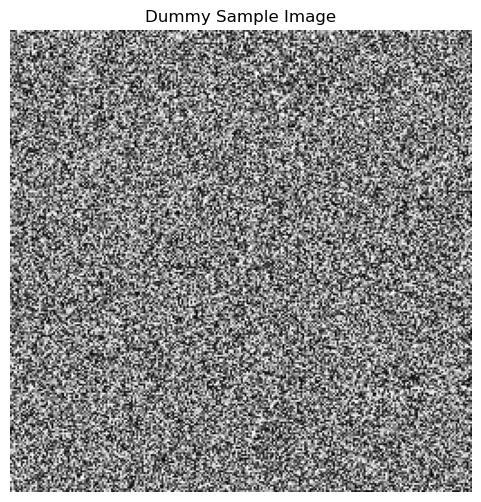

In [3]:
def load_dummy_image(size=256):
    """Simulate a 256×256 neonatal chest image."""
    return np.random.rand(size, size)

img1 = load_dummy_image()
img2 = load_dummy_image()

print(f"生成样本图像，尺寸: {img1.shape}")

plt.figure(figsize=(6, 6))
plt.imshow(img1, cmap='gray')
plt.title('Dummy Sample Image')
plt.axis('off')
plt.show()

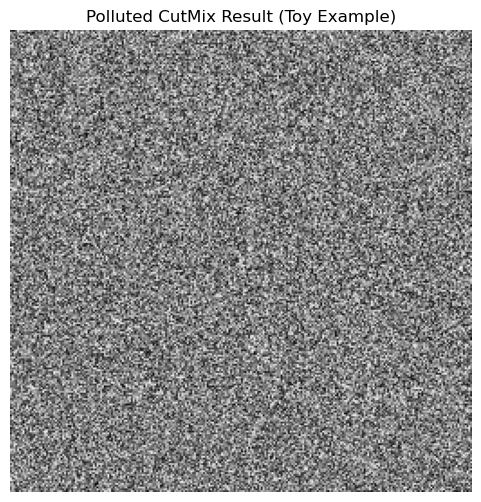

In [4]:
def toy_cutmix(x1, x2, lam=0.5):
    return lam * x1 + (1 - lam) * x2

mixed = toy_cutmix(img1, img2, lam=0.6)

plt.figure(figsize=(6, 6))
plt.imshow(mixed, cmap='gray')
plt.title('Polluted CutMix Result (Toy Example)')
plt.axis('off')
plt.show()

In [5]:
class DummyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(256*256, 2)

    def forward(self, x):
        x = x.reshape(1, -1)
        return self.fc(x)

model = DummyModel()
dummy_input = torch.tensor(img1, dtype=torch.float32)
output = model(dummy_input)

print(f"模型输出: {output.detach().numpy()}")

模型输出: [[-0.3163686  -0.11713177]]


In [6]:
def update_ema(student, teacher, alpha=0.99):
    for t_param, s_param in zip(teacher.parameters(), student.parameters()):
        t_param.data = alpha * t_param.data + (1 - alpha) * s_param.data

teacher = DummyModel()
update_ema(model, teacher)
print('EMA update applied.')

EMA update applied.


In [7]:
def mc_dropout_uncertainty(x, T=8):
    preds = []
    for _ in range(T):
        noise = np.random.normal(0, 0.1, x.shape)
        preds.append(x + noise)
    preds = np.stack(preds)
    return np.var(preds)

uncert = mc_dropout_uncertainty(img1)
print(f"不确定性估计值: {uncert}")

不确定性估计值: 0.09324434746952558


In [8]:
def dummy_inference(x):
    return {
        "Accuracy": 0.80,
        "Sensitivity": 0.78,
        "Precision": 0.82
    }

results = dummy_inference(img1)
print("模拟推理结果:")
for key, value in results.items():
    print(f"  {key}: {value}")

模拟推理结果:
  Accuracy: 0.8
  Sensitivity: 0.78
  Precision: 0.82
